In [41]:
# import packages
import numpy as np
import time
from os.path import exists
import matplotlib.pyplot as plt

In [42]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [43]:
from paraparticles.MPDO import MPDO

In [44]:
# n_coeffs check
from paraparticles.GellMann import gellmann_tilde
from paraparticles.Hamiltonian import n_loc

g = 2.5

tilde = gellmann_tilde(g)
n_coeffs = np.array([np.trace(n_loc @ tilde[j]) for j in range(9)])

for j in range(9):
    if j == 0:
        assert abs(n_coeffs[j]-2) < 1e-10
    elif j == 3:
        assert abs(n_coeffs[j] - (-g**2)) < 1e-10
    elif j == 8:
        assert abs(n_coeffs[j] - (-g**2/np.sqrt(3))) < 1e-10
    print(n_coeffs[j])

(2+0j)
0j
0j
(-6.25+0j)
0j
0j
0j
0j
(-3.6084391824351614+0j)


In [45]:
# build_MPDO_from_mps.py verification
from paraparticles.build_MPDO_from_mps import initial_MPDO_dict
from paraparticles.GellMann import gellmann_bar

g_test = 2.5
config = [1, 0, 2]  # flavor-a, vacuum, flavor-b
state_labels = ['flavor-a', 'vacuum', 'flavor-b']
expected_occ = [1, 0, 1]

rho_pure = [np.diag([0.,1.,0.]), np.diag([1.,0.,0.]), np.diag([0.,0.,1.])]

tilde_test = gellmann_tilde(g_test)
bar_test = gellmann_bar(g_test)
n_coeffs_test = np.array([np.trace(n_loc @ tilde_test[j]) for j in range(9)])

A_dict = initial_MPDO_dict(3, config, g_test)

# Step 1: A_temp coefficients per site
print("=== Step 1: A_temp coefficients per site ===")
for site in range(3):
    A_temp = A_dict[f"A{site}"].flatten()
    print(f"\nSite {site} ({state_labels[site]}):")
    for j in range(9):
        if abs(A_temp[j]) > 1e-12:
            print(f"  j={j}: {A_temp[j].real:.6f}")

# Step 2: measurement check
print("\n=== Step 2: measurement check (n_coeffs @ A_temp) ===")
for site in range(3):
    A_temp = A_dict[f"A{site}"].flatten()
    measured = sum(n_coeffs_test[j] * A_temp[j] for j in range(9)).real
    print(f"Site {site} ({state_labels[site]}): measured={measured:.6f}, expected={expected_occ[site]}")

# Step 3: g-scaling check for j=3,8
# A_temp[j] = Tr(bar(g)[j] @ rho) / 2  =  Tr(l_j @ rho) / (2*g^2)   for j=3,8
# val_g1    = Tr(bar(1)[j] @ rho)       =  Tr(l_j @ rho)              (raw, no /2)
# => ratio = 1 / (2*g^2)
print("\n=== Step 3: g-scaling check for j=3,8 ===")
for site in range(3):
    A_temp = A_dict[f"A{site}"].flatten()
    rho = rho_pure[site]
    for j in [3, 8]:
        val_g = A_temp[j].real
        val_g1 = np.trace(gellmann_bar(1)[j] @ rho).real
        if abs(val_g1) > 1e-12:
            ratio = val_g / val_g1
            print(f"Site {site} ({state_labels[site]}) j={j}: "
                  f"A_temp={val_g:.6f}, g=1 value={val_g1:.6f}, "
                  f"ratio={ratio:.4f} (expect 1/(2g^2)={1/(2*g_test**2):.4f})")

=== Step 1: A_temp coefficients per site ===

Site 0 (flavor-a):
  j=0: 0.333333
  j=3: -0.080000
  j=8: 0.046188

Site 1 (vacuum):
  j=0: 0.333333
  j=3: 0.080000
  j=8: 0.046188

Site 2 (flavor-b):
  j=0: 0.333333
  j=8: -0.092376

=== Step 2: measurement check (n_coeffs @ A_temp) ===
Site 0 (flavor-a): measured=1.000000, expected=1
Site 1 (vacuum): measured=-0.000000, expected=0
Site 2 (flavor-b): measured=1.000000, expected=1

=== Step 3: g-scaling check for j=3,8 ===
Site 0 (flavor-a) j=3: A_temp=-0.080000, g=1 value=-1.000000, ratio=0.0800 (expect 1/(2g^2)=0.0800)
Site 0 (flavor-a) j=8: A_temp=0.046188, g=1 value=0.577350, ratio=0.0800 (expect 1/(2g^2)=0.0800)
Site 1 (vacuum) j=3: A_temp=0.080000, g=1 value=1.000000, ratio=0.0800 (expect 1/(2g^2)=0.0800)
Site 1 (vacuum) j=8: A_temp=0.046188, g=1 value=0.577350, ratio=0.0800 (expect 1/(2g^2)=0.0800)
Site 2 (flavor-b) j=8: A_temp=-0.092376, g=1 value=-1.154701, ratio=0.0800 (expect 1/(2g^2)=0.0800)


In [46]:
# parameters
g = 2
L = 5
N = 4
Na = 2
t_hop = 1.0
W = 0.2
dt = 0.005
T = 20
# cutoff = 1e-16
seed = 42
rng = np.random.default_rng(seed)
# d = 3
chi = 10000
Nt = int(T/dt)
t_grid = np.linspace(0, T + dt, Nt + 1)


In [47]:
tr_TB = []
ni = np.zeros((L, Nt + 1))

In [48]:
mps_evolve = MPDO(L,N,Na,t_hop,W,dt,T,chi,seed,g)
for j in range(L):
    ni[j][0] = mps_evolve.ni_persite[j]
tr_TB.append(mps_evolve.tr_TEBD)  # t=0 trace

if exists("py_print.txt"):
    f = open("py_print.txt","w")
    f.write('New run\n')
    f.close
else:
    f = open("py_print.txt","x")
    f.write('New run\n')
    f.close()
for i in range(1, Nt + 1):
    t1 = time.time()
    mps_evolve.sweepU()
    t2 = time.time()
    f = open("py_print.txt","a")
    f.write('Time step = '+str(i)+', time taken = '+str(t2-t1)+' for each step\n')
    f.close()
    for j in range(L):
        ni[j][i] = mps_evolve.ni_persite[j]
    tr_TB.append(mps_evolve.tr_TEBD)

tr_TB = np.array(tr_TB).real

/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_4880/863106180.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  ni[j][0] = mps_evolve.ni_persite[j]
/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_4880/863106180.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  ni[j][i] = mps_evolve.ni_persite[j]


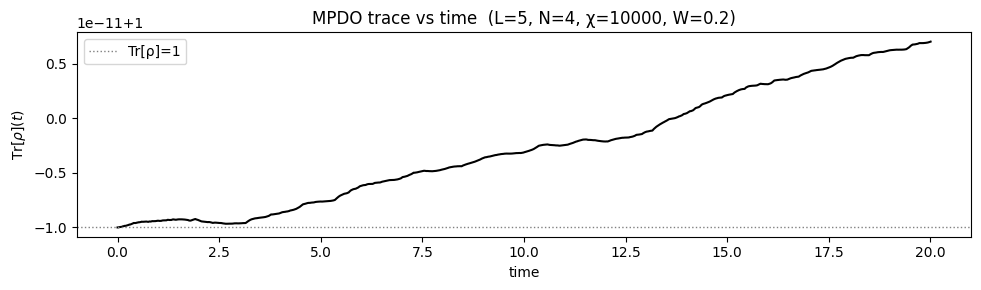

In [49]:
plt.figure(figsize=(10, 3))
plt.plot(t_grid, tr_TB, color='k')
plt.axhline(1, color='gray', linestyle=':', linewidth=1, label='Tr[ρ]=1')
plt.xlabel('time')
plt.ylabel(r'$\mathrm{Tr}[\rho](t)$')
plt.title(f'MPDO trace vs time  (L={L}, N={N}, χ={chi}, W={W})')
plt.legend()
plt.tight_layout()
plt.show()

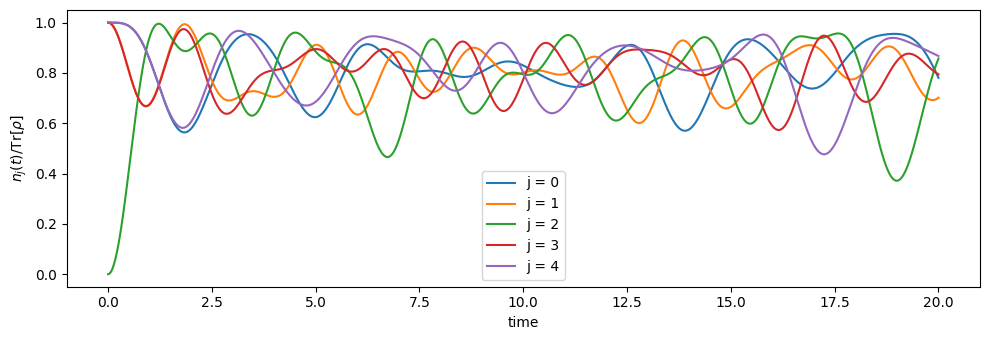

In [50]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(t_grid, ni[j, :] / tr_TB, label=f"j = {j}")
plt.xlabel('time')
plt.ylabel(r'$n_j(t) / \mathrm{Tr}[\rho]$')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
for j in range(L):
    print(ni[j,0])

1.0
0.9999999999999998
-8.326672684688674e-17
0.9999999999999998
1.0


In [52]:
3**6

729

In [53]:
# Build full Hamiltonian from the same disorder realization as TEBD
from paraparticles.ED import build_full_H_from_mpo
from paraparticles.Hamiltonian import build_MPO

MPO_ed = build_MPO(L, t_hop, mps_evolve.Omega_list, mps_evolve.q_list, mps_evolve.V_list)
H_ed   = build_full_H_from_mpo(MPO_ed)
E_vals, E_vecs = np.linalg.eigh(H_ed)   # E_vecs[:, k] is eigenstate |k⟩

In [54]:
# Initial state vector in the full 3^L Fock basis
# Basis ordering: |config[0], config[1], ..., config[L-1]⟩
# → linear index = Σ_j config[j] * 3^(L-1-j)
psi0 = np.zeros(3**L, dtype=complex)
idx  = sum(mps_evolve.config[j] * 3**(L - 1 - j) for j in range(L))
psi0[idx] = 1.0

# n_j operators embedded in the full 3^L Hilbert space
I3        = np.eye(3, dtype=complex)
n_loc_mat = np.diag([0., 1., 1.]).astype(complex)

n_ops = []
for j in range(L):
    op = np.array([[1.0 + 0j]])
    for s in range(L):
        op = np.kron(op, n_loc_mat if s == j else I3)
    n_ops.append(op)

In [55]:
# Exact time evolution and measurement of n_j(t)
c_k   = E_vecs.conj().T @ psi0          # ⟨k|ψ₀⟩ for each eigenstate k
ni_ED = np.zeros((L, Nt + 1), dtype=float)

for ti, t in enumerate(t_grid):
    psi_t = E_vecs @ (c_k * np.exp(-1j * E_vals * t))
    for j in range(L):
        ni_ED[j, ti] = np.real(psi_t.conj() @ (n_ops[j] @ psi_t))

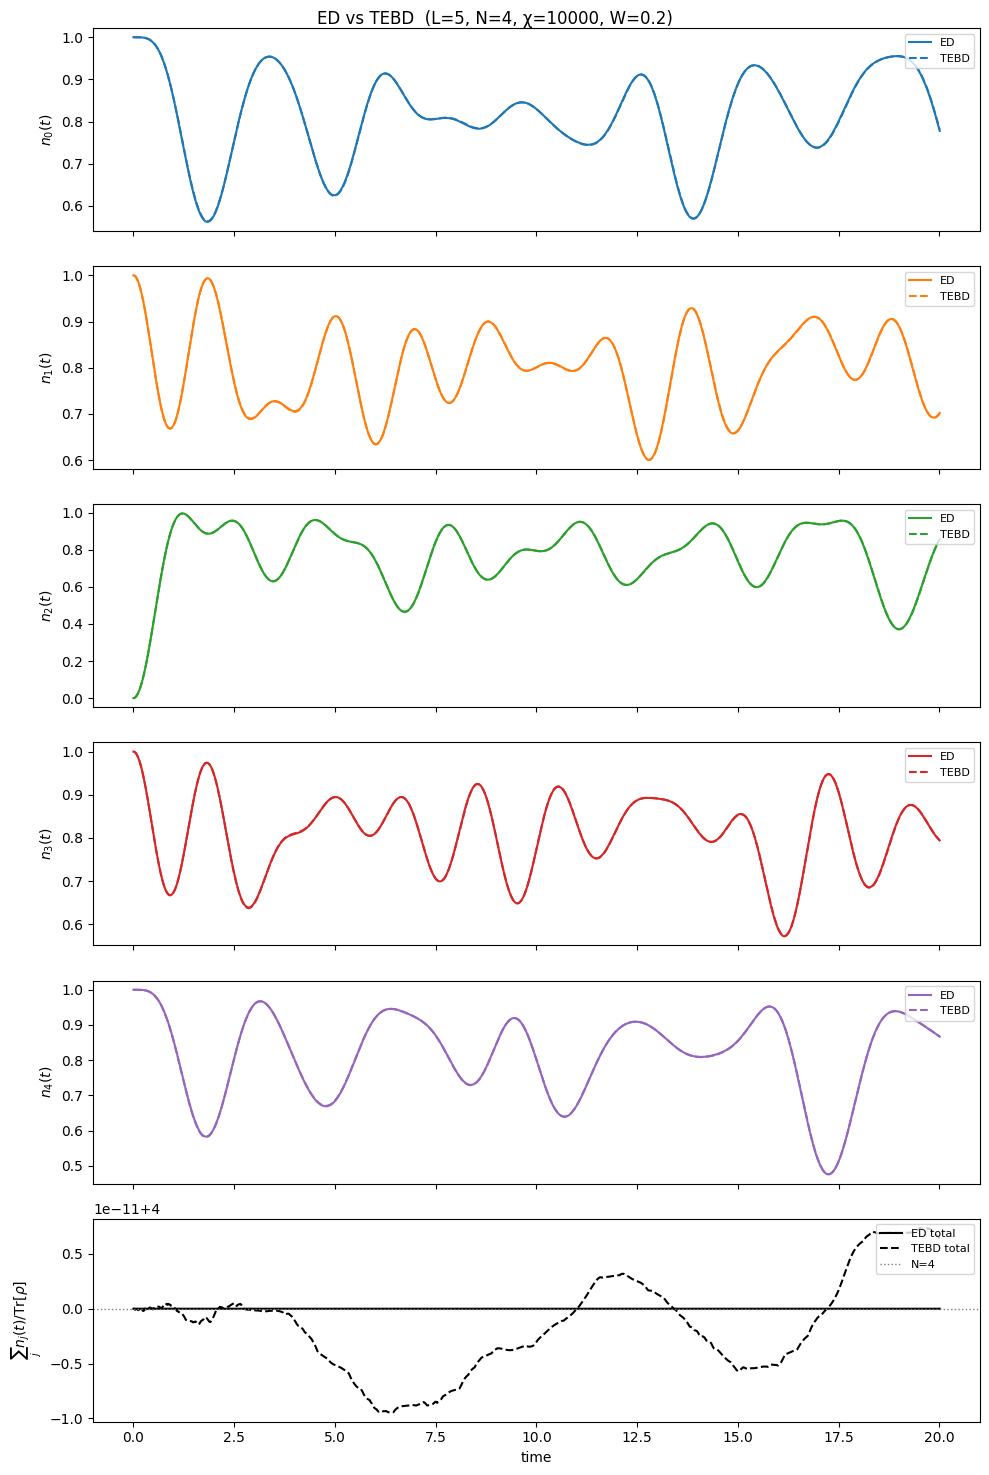

In [56]:
fig, axes = plt.subplots(L + 1, 1, figsize=(10, 2.5 * (L + 1)), sharex=True)

for j in range(L):
    axes[j].plot(t_grid, ni_ED[j, :],          '-',  color=f'C{j}', label='ED')
    axes[j].plot(t_grid, ni[j, :] / tr_TB,     '--', color=f'C{j}', label='TEBD')
    axes[j].set_ylabel(f'$n_{{{j}}}(t)$')
    axes[j].legend(loc='upper right', fontsize=8)

axes[L].plot(t_grid, np.sum(ni_ED, axis=0),             '-k',  label='ED total')
axes[L].plot(t_grid, np.sum(ni, axis=0) / tr_TB,        '--k', label='TEBD total')
axes[L].axhline(N, color='gray', linestyle=':', linewidth=1, label=f'N={N}')
axes[L].set_ylabel(r'$\sum_j n_j(t) / \mathrm{Tr}[\rho]$')
axes[L].set_xlabel('time')
axes[L].legend(loc='upper right', fontsize=8)

plt.suptitle(f'ED vs TEBD  (L={L}, N={N}, χ={chi}, W={W})', fontsize=12)
plt.tight_layout()
plt.show()